In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

In [3]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/student_performance_dataset.csv")

# Drop 'Gender' and rows with missing values
df = df.drop(columns=['Gender'])
df = df.dropna()


In [4]:
import os

# List files in the directory where the dataset is expected
# If the directory path is different, please update it accordingly.
print(os.listdir('/content/drive/MyDrive/Major Project/'))

['MAJOR PROJECT FINAL ', 'Major_Project_DSAIML_Report.gdoc', 'Major_Project_DSAIML_Report.pdf', 'Major_project.ipynb']


In [5]:
# Separate features and target
X = df.drop(columns=["Final_Exam_Score", "Pass_Fail"])
y = df["Final_Exam_Score"]

# Identify column types
categorical_cols = ["Parental_Education_Level", "Internet_Access_at_Home", "Extracurricular_Activities"]
numerical_cols = ["Study_Hours_per_Week", "Attendance_Rate", "Past_Exam_Scores"]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols)
    ]
)


In [6]:
# Create XGBoost regression pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        objective="reg:squarederror"
    ))
])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Study_Hours_per_Week',
                                                   'Attendance_Rate',
                                                   'Past_Exam_Scores']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Parental_Education_Level',
                                                   'Internet_Access_at_Home',
                                                   'Extracurricular_Activities'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsam...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [7]:
# Predict and evaluate
y_pred = xgb_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", round(mse, 2))
print("R^2 Score:", round(r2, 2))

Mean Squared Error: 10.5
R^2 Score: 0.75


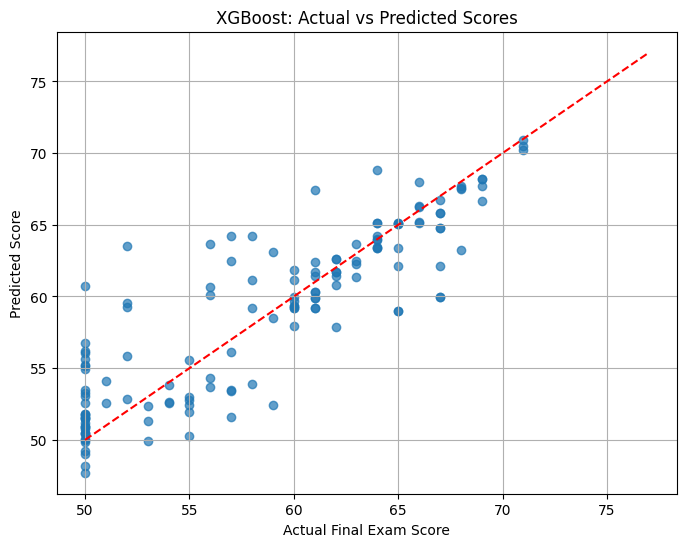

In [8]:
# Plot actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Final Exam Score")
plt.ylabel("Predicted Score")
plt.title("XGBoost: Actual vs Predicted Scores")
plt.grid(True)
plt.show()

In [9]:
# Create a single test case with user-defined input
custom_input = pd.DataFrame([{
    "Study_Hours_per_Week": 8,
    "Attendance_Rate": 34,
    "Past_Exam_Scores": 10,
    "Parental_Education_Level": "Bachelors",
    "Internet_Access_at_Home": "Yes",
    "Extracurricular_Activities": "No"
}])

# Predict final score for the custom input
custom_prediction = xgb_pipeline.predict(custom_input)

print("Predicted Final Exam Score:", round(custom_prediction[0], 2))

Predicted Final Exam Score: 49.62


In [10]:
# Export predictions and data for Power BI
results_df = pd.DataFrame({
    'Actual_Score': y_test.values,
    'Predicted_Score': y_pred,
    'Error': y_test.values - y_pred
})

results_df.to_csv('predictions_output.csv', index=False)
df.to_csv('student_data_cleaned.csv', index=False)

print("✅ Done! Two CSV files are ready to download.")

✅ Done! Two CSV files are ready to download.


In [11]:
from google.colab import files
files.download('predictions_output.csv')
files.download('student_data_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
print(df.columns.tolist())

['Student_ID', 'Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores', 'Parental_Education_Level', 'Internet_Access_at_Home', 'Extracurricular_Activities', 'Final_Exam_Score', 'Pass_Fail']
